# Video Game Sales

In [47]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [48]:
df = pd.read_csv('data-set/vgsales.csv')
print(df.head())
print(df.shape)

   Rank                      Name Platform    Year         Genre Publisher  \
0     1                Wii Sports      Wii  2006.0        Sports  Nintendo   
1     2         Super Mario Bros.      NES  1985.0      Platform  Nintendo   
2     3            Mario Kart Wii      Wii  2008.0        Racing  Nintendo   
3     4         Wii Sports Resort      Wii  2009.0        Sports  Nintendo   
4     5  Pokemon Red/Pokemon Blue       GB  1996.0  Role-Playing  Nintendo   

   NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  
0     41.49     29.02      3.77         8.46         82.74  
1     29.08      3.58      6.81         0.77         40.24  
2     15.85     12.88      3.79         3.31         35.82  
3     15.75     11.01      3.28         2.96         33.00  
4     11.27      8.89     10.22         1.00         31.37  
(16598, 11)


In [49]:
print(df.info())
print(df.isnull().sum())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB
None
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64
               Rank          Yea

In [50]:
# cleaning and preprocessing
df = df.dropna(subset=['Year'])
df['Publisher'] = df['Publisher'].fillna('Unknown')

# remove outliers
Q1 = df['Global_Sales'].quantile(0.25)
Q3 = df['Global_Sales'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df = df[(df['Global_Sales'] >= lower) & (df['Global_Sales'] <= upper)]
print(f"after cleaning: {len(df)} rows")

# make some new features
df['Total_Regional_Sales'] = df['NA_Sales'] + df['EU_Sales'] + df['JP_Sales'] + df['Other_Sales']
df['Years_Since_Release'] = 2024 - df['Year']
df['Popular_in_NA'] = (df['NA_Sales'] > df['NA_Sales'].median()).astype(int)

# encode categorical stuff
le_platform = LabelEncoder()
le_genre = LabelEncoder()
le_publisher = LabelEncoder()
df['Platform_Encoded'] = le_platform.fit_transform(df['Platform'])
df['Genre_Encoded'] = le_genre.fit_transform(df['Genre'])
df['Publisher_Encoded'] = le_publisher.fit_transform(df['Publisher'])

print(df.shape)

after cleaning: 14500 rows
(14500, 17)


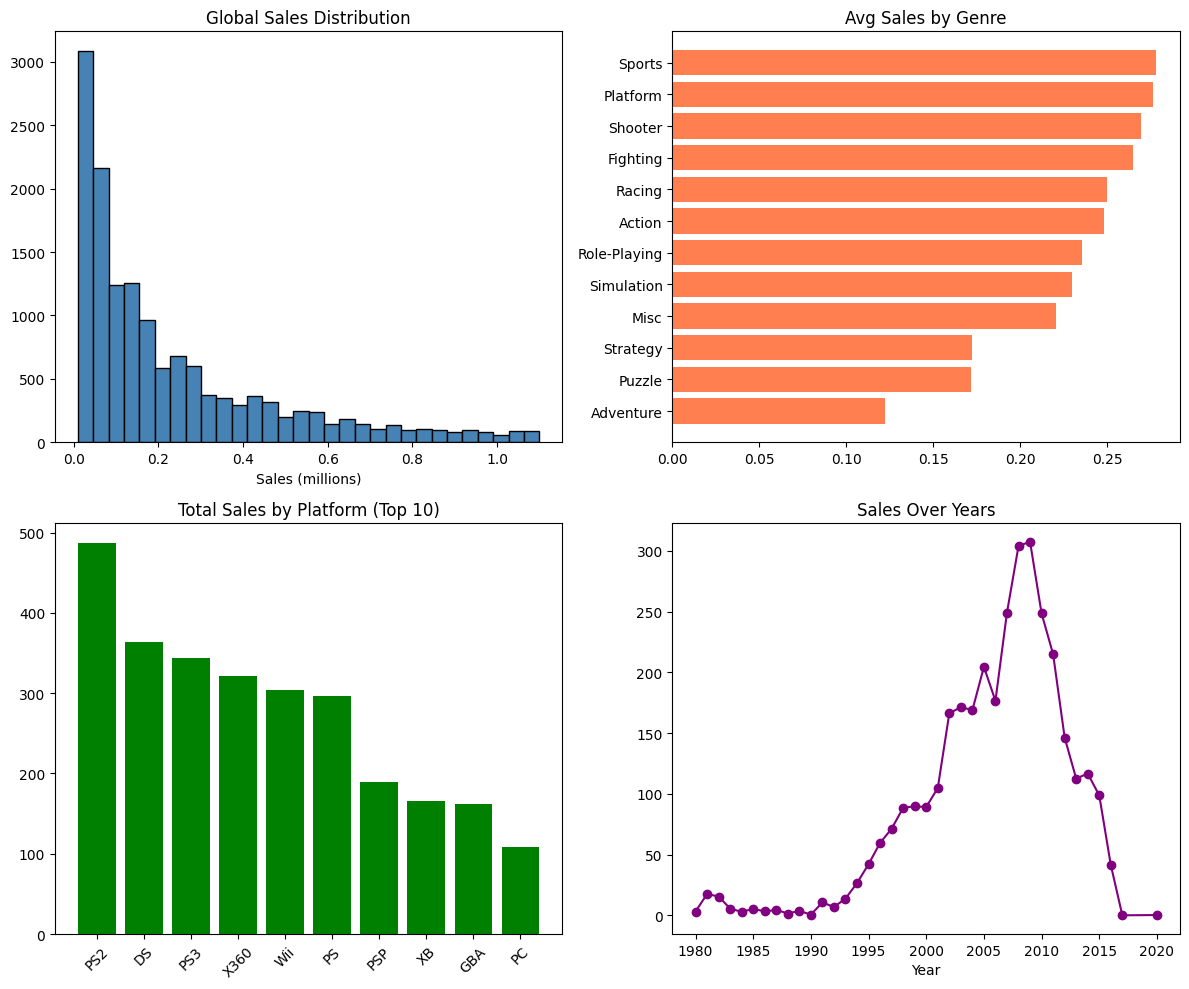

In [51]:
# distribution of sales
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0,0].hist(df['Global_Sales'], bins=30, color='steelblue', edgecolor='black')
axes[0,0].set_title('Global Sales Distribution')
axes[0,0].set_xlabel('Sales (millions)')

# sales by genre
genre_sales = df.groupby('Genre')['Global_Sales'].mean().sort_values(ascending=True)
axes[0,1].barh(genre_sales.index, genre_sales.values, color='coral')
axes[0,1].set_title('Avg Sales by Genre')

# sales by platform top 10
platform_sales = df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False).head(10)
axes[1,0].bar(platform_sales.index, platform_sales.values, color='green')
axes[1,0].set_title('Total Sales by Platform (Top 10)')
axes[1,0].tick_params(axis='x', rotation=45)

# sales over years
year_sales = df.groupby('Year')['Global_Sales'].sum()
axes[1,1].plot(year_sales.index, year_sales.values, marker='o', color='purple')
axes[1,1].set_title('Sales Over Years')
axes[1,1].set_xlabel('Year')

plt.tight_layout()
plt.show()

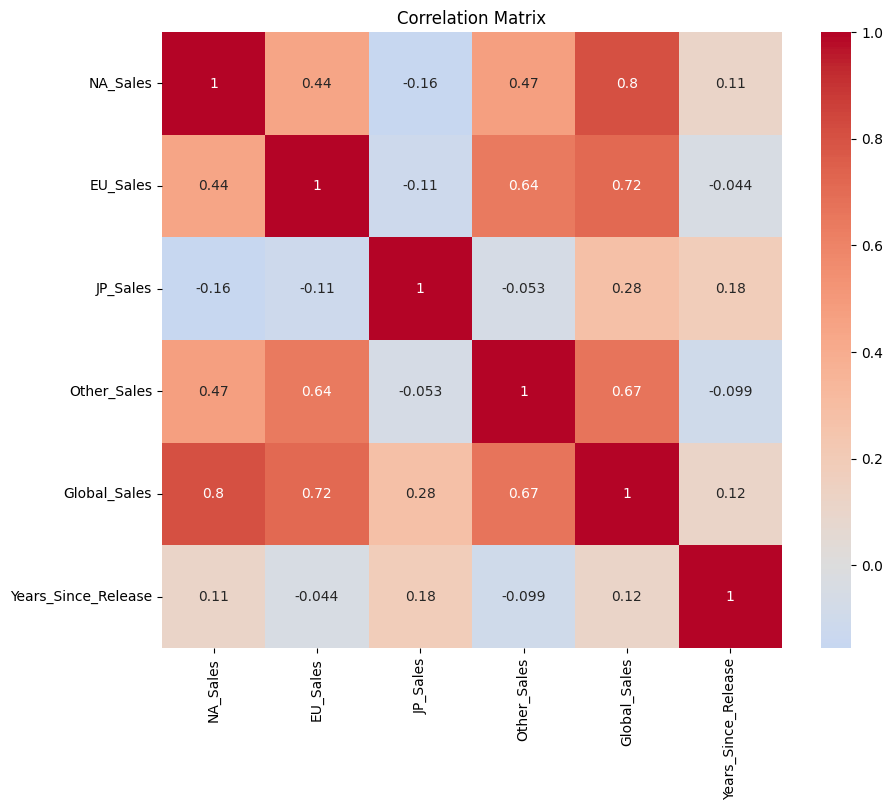

In [52]:
# correlation heatmap
numeric_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Years_Since_Release']
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

split data

In [53]:
X = df[['Platform_Encoded', 'Genre_Encoded', 'Publisher_Encoded', 'Year', 
        'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 
        'Years_Since_Release', 'Popular_in_NA']]
y = df['Global_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"train: {X_train.shape[0]}, test: {X_test.shape[0]}")

train: 11600, test: 2900


In [54]:
# trying different models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'SVM': SVR(kernel='rbf'),
    'KNN': KNeighborsRegressor(n_neighbors=5)
}

results = []

for name, model in models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    pipe.fit(X_train, y_train)
    
    train_pred = pipe.predict(X_train)
    test_pred = pipe.predict(X_test)
    
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)
    mae = mean_absolute_error(y_test, test_pred)
    rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    
    cv = cross_val_score(pipe, X_train, y_train, cv=5, scoring='r2')
    
    results.append({
        'Model': name,
        'Train R2': train_r2,
        'Test R2': test_r2,
        'CV Mean': cv.mean(),
        'CV Std': cv.std(),
        'MAE': mae,
        'RMSE': rmse
    })
    
    print(f"{name}: Train R2={train_r2:.4f}, Test R2={test_r2:.4f}, CV={cv.mean():.4f} (+/- {cv.std():.4f})")

results_df = pd.DataFrame(results).sort_values('Test R2', ascending=False)
print("\n")
print(results_df)

Linear Regression: Train R2=0.9996, Test R2=0.9996, CV=0.9996 (+/- 0.0000)
Decision Tree: Train R2=1.0000, Test R2=0.9838, CV=0.9875 (+/- 0.0022)
Random Forest: Train R2=0.9992, Test R2=0.9899, CV=0.9940 (+/- 0.0013)
Gradient Boosting: Train R2=0.9956, Test R2=0.9942, CV=0.9945 (+/- 0.0004)
SVM: Train R2=0.9730, Test R2=0.9706, CV=0.9699 (+/- 0.0020)
KNN: Train R2=0.9875, Test R2=0.9781, CV=0.9781 (+/- 0.0016)


               Model  Train R2   Test R2   CV Mean    CV Std       MAE  \
0  Linear Regression  0.999572  0.999582  0.999571  0.000014  0.002984   
3  Gradient Boosting  0.995648  0.994187  0.994476  0.000402  0.011640   
2      Random Forest  0.999248  0.989884  0.993977  0.001263  0.008107   
1      Decision Tree  0.999997  0.983831  0.987547  0.002226  0.011501   
5                KNN  0.987512  0.978110  0.978071  0.001586  0.023566   
4                SVM  0.973021  0.970571  0.969901  0.002049  0.033887   

       RMSE  
0  0.005120  
3  0.019085  
2  0.025177  
1  0.0318

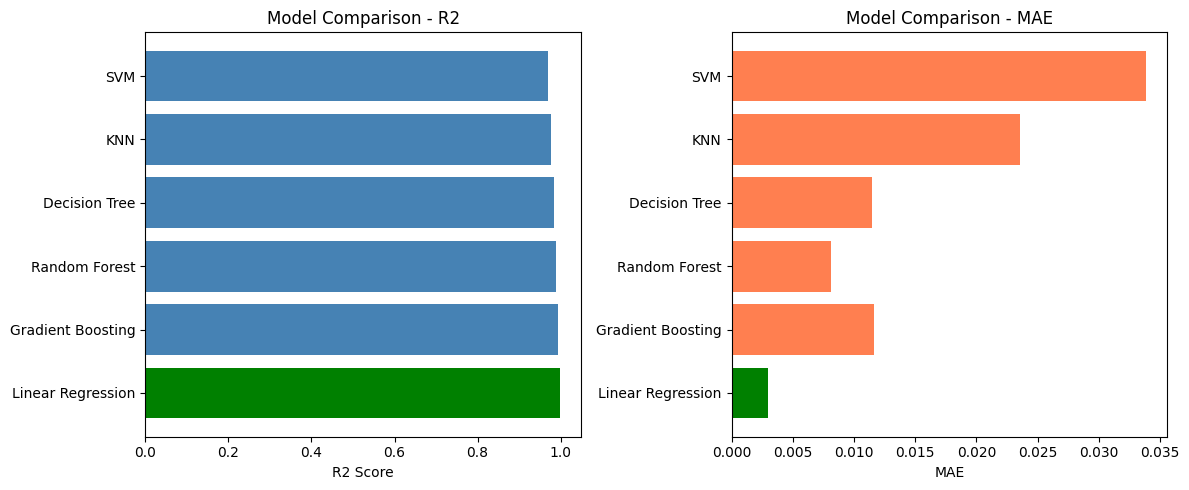

In [55]:
# plot model comparison
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
colors = ['green' if x == results_df['Test R2'].max() else 'steelblue' for x in results_df['Test R2']]
plt.barh(results_df['Model'], results_df['Test R2'], color=colors)
plt.xlabel('R2 Score')
plt.title('Model Comparison - R2')

plt.subplot(1, 2, 2)
colors = ['green' if x == results_df['MAE'].min() else 'coral' for x in results_df['MAE']]
plt.barh(results_df['Model'], results_df['MAE'], color=colors)
plt.xlabel('MAE')
plt.title('Model Comparison - MAE')

plt.tight_layout()
plt.show()

cross validation for best model

In [56]:
# cross validation on random forest (best model from comparison)
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=42, n_estimators=100))
])

cv_scores = cross_val_score(rf_pipeline, X_train, y_train, cv=5, scoring='r2')

print("5-Fold Cross Validation Results:")
print(f"CV Scores: {cv_scores}")
print(f"Average R2: {cv_scores.mean():.4f}")
print(f"Std Dev: {cv_scores.std():.4f}")
print(f"Score Range: {cv_scores.min():.4f} to {cv_scores.max():.4f}")

5-Fold Cross Validation Results:
CV Scores: [0.99494261 0.99559725 0.9937485  0.99190608 0.99369233]
Average R2: 0.9940
Std Dev: 0.0013
Score Range: 0.9919 to 0.9956


model selection - Random Forest selected because it handles non-linear relationships well, works good with mixed feature types (encoded categorical + numerical), and doesnt overfit easily compared to single decision tree. also ensemble methods usually give better results on tabular data like this

In [57]:
best_name = results_df.iloc[0]['Model']
print(f"best model based on test R2: {best_name}")
print("going with Random Forest for tuning")

best model based on test R2: Linear Regression
going with Random Forest for tuning


hyperparameter tuning

In [58]:
# tune random forest
rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=42))
])

param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [5, 10, 15, None],
    'model__min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(rf_pipe, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print(f"best params: {grid.best_params_}")
print(f"best cv score: {grid.best_score_:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
best params: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}
best cv score: 0.9940


get best model

In [59]:
best_model = grid.best_estimator_
print("using tuned random forest as final model")

using tuned random forest as final model


model evaluation

In [60]:
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Final Model Performance:")
print(f"R2 Score: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

Final Model Performance:
R2 Score: 0.9899
MAE: 0.0081
MSE: 0.0006
RMSE: 0.0252


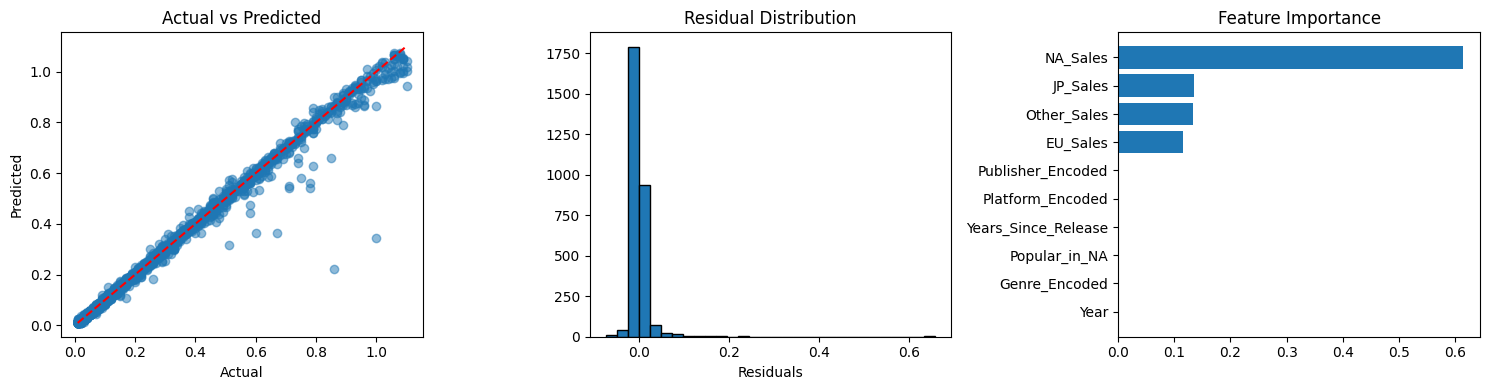

In [61]:
# plots for evaluation
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# actual vs predicted
axes[0].scatter(y_test, y_pred, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Actual vs Predicted')

# residuals
residuals = y_test - y_pred
axes[1].hist(residuals, bins=30, edgecolor='black')
axes[1].set_xlabel('Residuals')
axes[1].set_title('Residual Distribution')

# feature importance
rf_model = best_model.named_steps['model']
importance = rf_model.feature_importances_
sorted_idx = np.argsort(importance)
axes[2].barh(range(len(sorted_idx)), importance[sorted_idx])
axes[2].set_yticks(range(len(sorted_idx)))
axes[2].set_yticklabels([X.columns[i] for i in sorted_idx])
axes[2].set_title('Feature Importance')

plt.tight_layout()
plt.show()

save model

In [62]:
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('label_encoders.pkl', 'wb') as f:
    pickle.dump({
        'platform': le_platform,
        'genre': le_genre,
        'publisher': le_publisher
    }, f)

print("saved!")

saved!
